<h1>Load Data</h1>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix
from pathlib import Path
import itertools
import os
import shutil
import random
import glob
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

random.seed(42)

#Organize data into train, test and validation sets
notebook_dir = Path.cwd() #get current notebook dir

data_folder = notebook_dir.parent / "data" #create path to data folder

os.chdir(data_folder)

#create folders inside data
dirs = [
    "train/dog", "train/cat",
    "valid/dog", "valid/cat",
    "test/dog",  "test/cat"
]

for d in dirs:
    (data_folder / d).mkdir(parents=True, exist_ok=True)


#Base folders
target_folders = ["train", "valid", "test"]

#Create target folders if they don't exist
for split in target_folders:
    for cls in ["cat", "dog"]:
        folder = data_folder / split / cls
        folder.mkdir(parents=True, exist_ok=True)

#Source folders
cat_src = data_folder / "Cat"
dog_src = data_folder / "Dog"

#Function to move images randomly
def move_images(src_folder, dst_folder, n):
    imgs = list(src_folder.glob("*.jpg"))
    sampled = random.sample(imgs, n)
    for img_path in sampled:
        shutil.copy2(str(img_path), dst_folder)

#Move images
move_images(cat_src, data_folder / "train" / "cat", 500)
move_images(dog_src, data_folder / "train" / "dog", 500)
move_images(cat_src, data_folder / "valid" / "cat", 100)
move_images(dog_src, data_folder / "valid" / "dog", 100)
move_images(cat_src, data_folder / "test" / "cat", 100)
move_images(dog_src, data_folder / "test" / "dog", 100)

<h3>Look at some images of the dataset</h3>

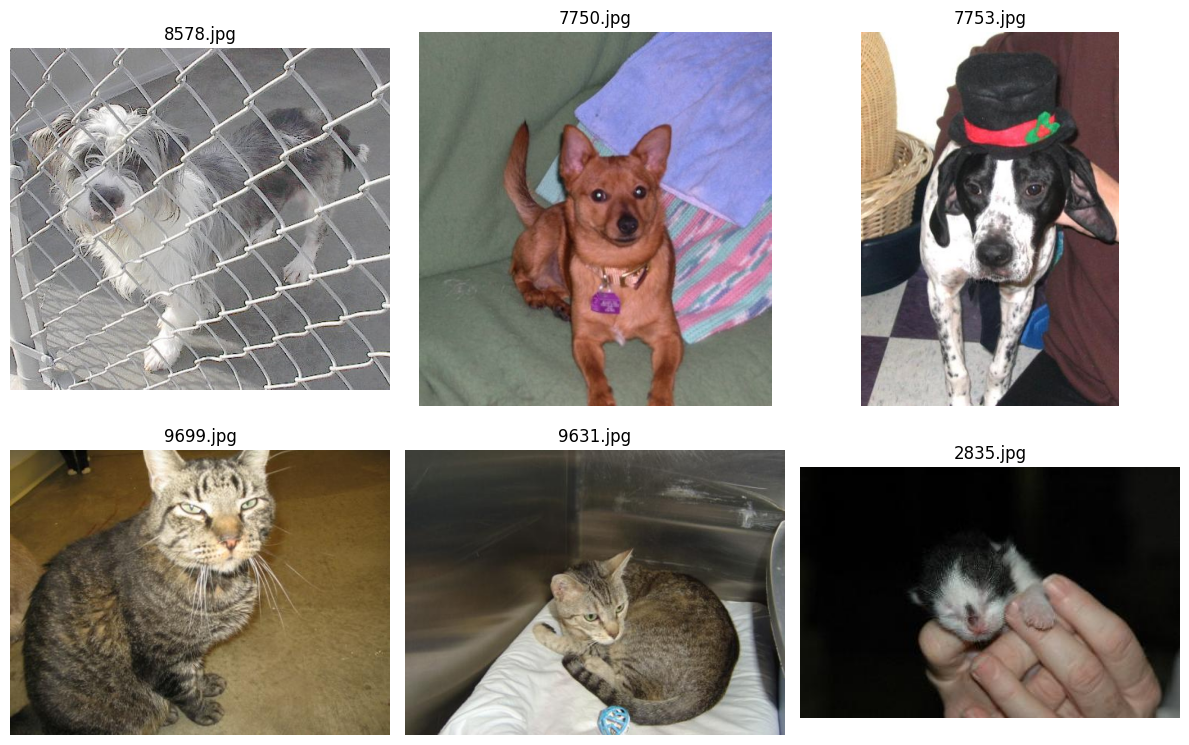

In [2]:
import pandas as pd
from PIL import Image
import imagesize

root = "../data/"

imgs = [img for img in Path(root).rglob("*.jpg")] #get all images from the subfolders

sampled = random.sample(imgs, 6)

plt.figure(figsize=(12, 8)) 
for i, filename in enumerate(sampled, 1):
     img_path = Path(root) / filename 
     img = Image.open(img_path) 
     plt.subplot(2, 3, i) 
     plt.imshow(img) 
     plt.axis("off") 
     plt.title(img_path.name) 
plt.tight_layout() 
plt.show()

Visualizing image sizes
<p>Before we resize the images we check out the datasets qualities.
<ul>
    <li>Size</li>
    <li>Width</li>
    <li>Height</li>
</ul>


In [3]:
sampled_imgs = random.sample(imgs, 3000)
img_meta = {}
for f in sampled_imgs: 
    img_meta[str(f)] = imagesize.get(f)  #Here we get the images resolution (f represents one image it is a path object)

#Convert into dataframe
img_meta_df = pd.DataFrame.from_dict([img_meta]).T.reset_index().set_axis(['FileName', 'Size'], axis='columns')
img_meta_df[["Width", "Height"]] = pd.DataFrame(img_meta_df["Size"].tolist(), index=img_meta_df.index)
img_meta_df["Aspect Ratio"] = round(img_meta_df["Width"] / img_meta_df["Height"], 2)

print(f'Total Nr of Images in the dataset: {len(img_meta_df)}')
img_meta_df.head()


Total Nr of Images in the dataset: 3000


,FileName,Size,Width,Height,Aspect Ratio
0,..\data\Dog\260.jpg,"(373, 500)",373,500,0.75
1,..\data\Dog\10537.jpg,"(396, 382)",396,382,1.04
2,..\data\train\cat\7881.jpg,"(500, 474)",500,474,1.05
3,..\data\Dog\3004.jpg,"(263, 369)",263,369,0.71
4,..\data\Cat\11725.jpg,"(411, 322)",411,322,1.28


Text(0, 0.5, 'Height')

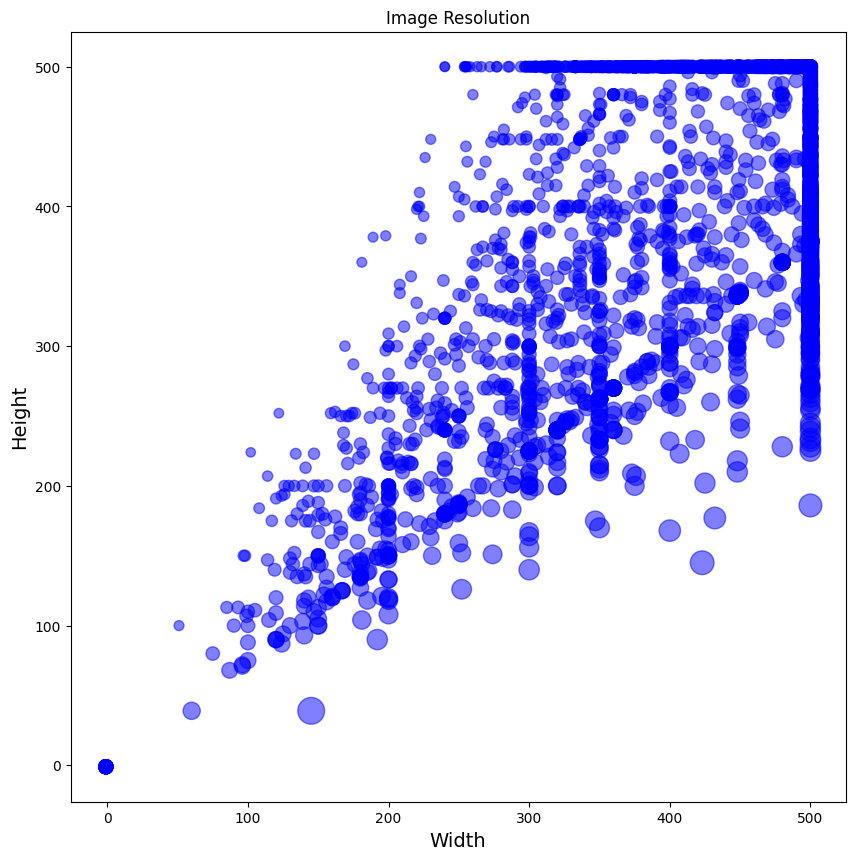

In [4]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
points = ax.scatter(img_meta_df.Width, img_meta_df.Height, color='blue', alpha=0.5, s=img_meta_df["Aspect Ratio"]*100, picker=True)
ax.set_title("Image Resolution")
ax.set_xlabel("Width", size=14)
ax.set_ylabel("Height", size=14)

These results show us that many of the images have a quadratic form. And we can resize them without (much) cropping or padding.

<h3>Greyscale pixel intensity histogram across dataset</h3>
<p>50 sampled images; 0=black, 255=white; it seems to be a normal distribution without missing ranges


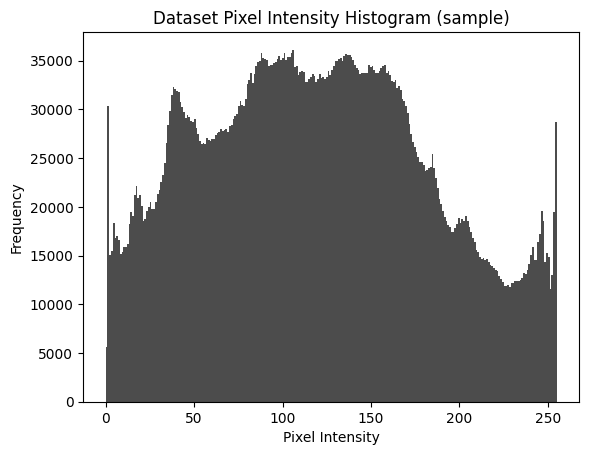

In [5]:
imgs = random.sample(imgs, 50)

all_pixels = []

for img_path in imgs:
    img = Image.open(img_path).convert("L")
    pixels = np.array(img).flatten()
    all_pixels.extend(pixels)

plt.hist(all_pixels, bins=256, range=(0, 255), color='black', alpha=0.7)
plt.title("Dataset Pixel Intensity Histogram (sample)")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()


Preprocessing pipeline with tf keras
<p>Images are resized to 224x224 

In [6]:
batch_size = 32
img_size = (224, 224)

train_batches = tf.keras.preprocessing.image_dataset_from_directory(
    directory=f"{data_folder}/train",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

valid_batches = tf.keras.preprocessing.image_dataset_from_directory(
    directory=f"{data_folder}/valid",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

test_batches = tf.keras.preprocessing.image_dataset_from_directory(
    directory=f"{data_folder}/test",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

#Preprocessing layers normalizes pixels to [0,1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

#Is only applied to training set --- the question is if we really need it?We have 25000 pictures at hand
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.4),
    tf.keras.layers.RandomGaussianBlur(1.0)
])

train_batches = train_batches.map(lambda x, y: (data_augmentation(normalization_layer(x)), y))
valid_batches = valid_batches.map(lambda x, y: (normalization_layer(x), y))
test_batches  = test_batches.map(lambda x, y: (normalization_layer(x), y))

# Optimize performance with caching & prefetching
train_batches = train_batches.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
valid_batches = valid_batches.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_batches  = test_batches.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 2000 files belonging to 2 classes.
Found 400 files belonging to 2 classes.
Found 400 files belonging to 2 classes.


Images batch shape: (32, 224, 224, 3)
Labels batch shape: (32, 2)


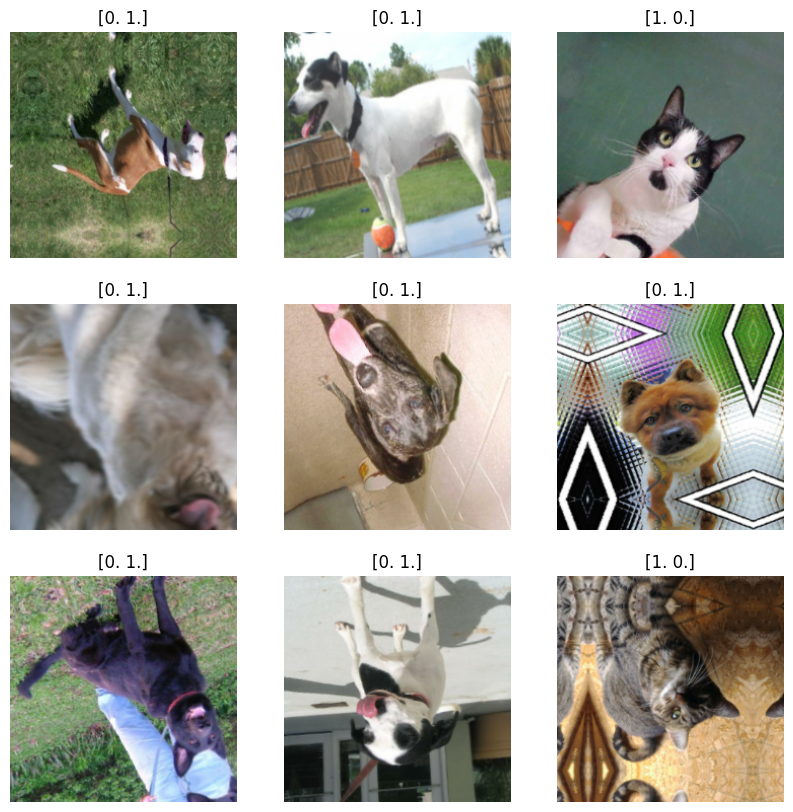

In [7]:
for images, labels in train_batches.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)

    #Plot first 9 images in the batch
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(labels[i].numpy())
        plt.axis("off")
    plt.show()


<h4>Reflection padding is the default resizing option; it looks strange but has multiple advantages over just black or white boarders.</h4>
<p>Copied from https://medium.com/@Orca_Thunder/image-padding-techniques-reflect-padding-part-2-5a013cd96537<br><br>
    Reduces Border Effects: Reduces border effects that can occur when applying filters or other image processing techniques to the edges of an image. Without reflect padding, the edges of the image would be processed differently from the rest of the image, leading to artifacts and distortions.</p>
    <p>Preserves Image Features: Preserves the features of the original image by creating a smooth transition from the original image to the padded border. This ensures that the padded image retains the same features as the original image.
    Increases Convolutional Neural Network Accuracy: Allows for larger convolutional filter sizes to be used. When dealing with CNNs, larger filter sizes are beneficial as they allow for more complex operations to be performed on the image, leading to improved accuracy and better results</p>.
    <p>Faster Processing and Improved Performance: It can help to reduce the amount of data that needs to be processed. As the image is symmetrically reflected at the edges, the amount of data that needs to be calculated is reduced as the pixels do not need to be calculated separately. This allows for faster processing times and improved performance.
</p>